Generating synthetic dataset...
Dataset Preview:


,age,training_load,previous_injuries,recovery_time,sleep_quality,nutrition_score,muscle_fatigue,joint_flexibility,hydration_level,playing_surface,injury_risk,injury_location,recovery_period
0,24,6.987127,0,0.000000,8.041873,6.270289,2.968945,2.109866,2.536914,3,0,0,0.0
1,37,4.462918,3,52.165929,5.075520,5.899104,3.935985,4.608733,3.404889,3,1,2,31.0
2,32,19.304654,5,55.414938,8.163698,3.103667,7.805730,4.156388,5.582020,0,1,4,33.0
3,28,15.638408,5,28.704187,5.377589,6.739967,4.543796,7.955561,2.327085,0,1,3,20.0
4,25,21.520233,2,22.537675,4.705308,8.380608,6.473902,8.228535,6.504901,3,0,0,0.0



Dataset Information:


,age,training_load,previous_injuries,recovery_time,sleep_quality,nutrition_score,muscle_fatigue,joint_flexibility,hydration_level,playing_surface,injury_risk,injury_location,recovery_period
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,28.845000,14.048419,2.554000,27.033014,6.935271,5.470413,5.436880,5.493294,5.305381,1.529000,0.369000,1.046000,8.525000
std,6.854046,6.419764,1.711728,18.997498,1.724776,2.581018,2.614336,2.581984,2.574694,1.134216,0.482775,1.547346,13.089718
min,18.000000,3.101905,0.000000,0.000000,4.000184,1.002043,1.035265,1.002169,1.002186,0.000000,0.000000,0.000000,0.000000
25%,23.000000,8.185364,1.000000,9.770746,5.402157,3.233306,3.174801,3.254067,3.097203,0.000000,0.000000,0.000000,0.000000
50%,29.000000,14.302565,3.000000,26.678968,6.920188,5.404116,5.375658,5.423808,5.182949,2.000000,0.000000,0.000000,0.000000
75%,35.000000,19.514289,4.000000,43.776016,8.399727,7.738276,7.641720,7.821520,7.373371,3.000000,1.000000,2.000000,17.000000
max,40.000000,24.987102,5.000000,59.880147,9.997346,9.979745,9.995146,9.992866,9.990142,3.000000,1.000000,5.000000,66.000000



Target Variable Distribution:
Injury Risk: {0: 631, 1: 369}
Injury Location: {0: 631, 3: 123, 2: 81, 4: 70, 1: 60, 5: 35}


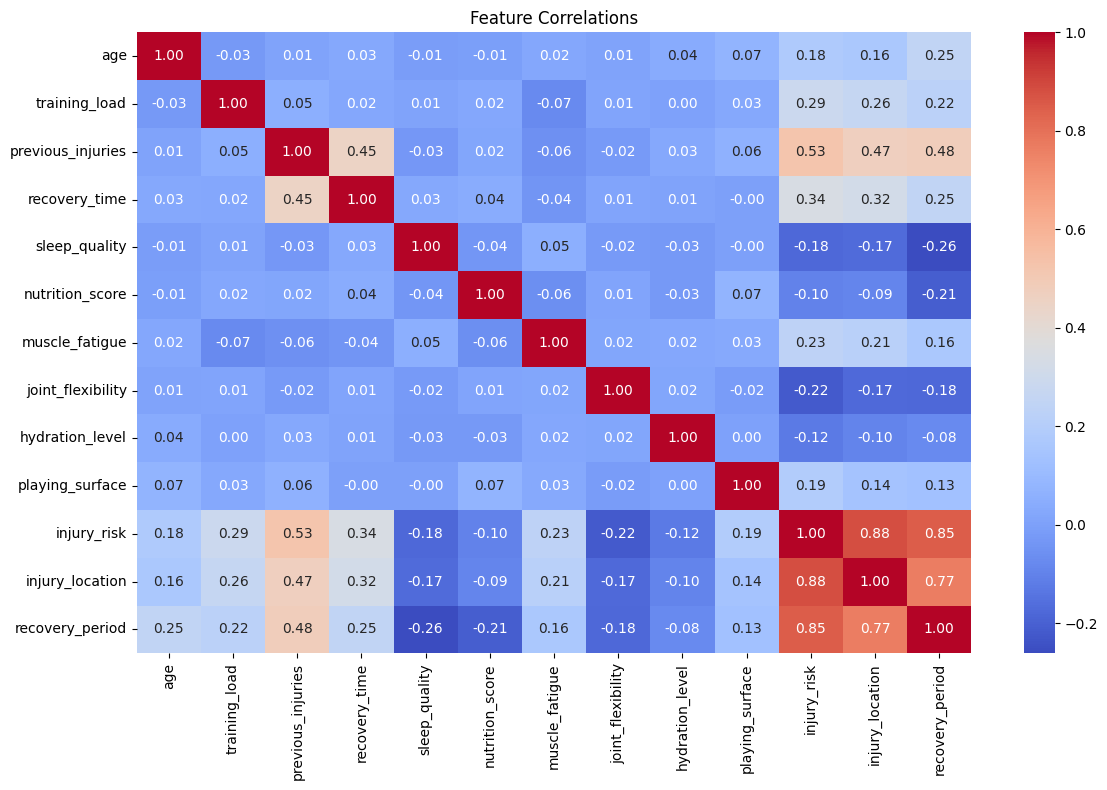

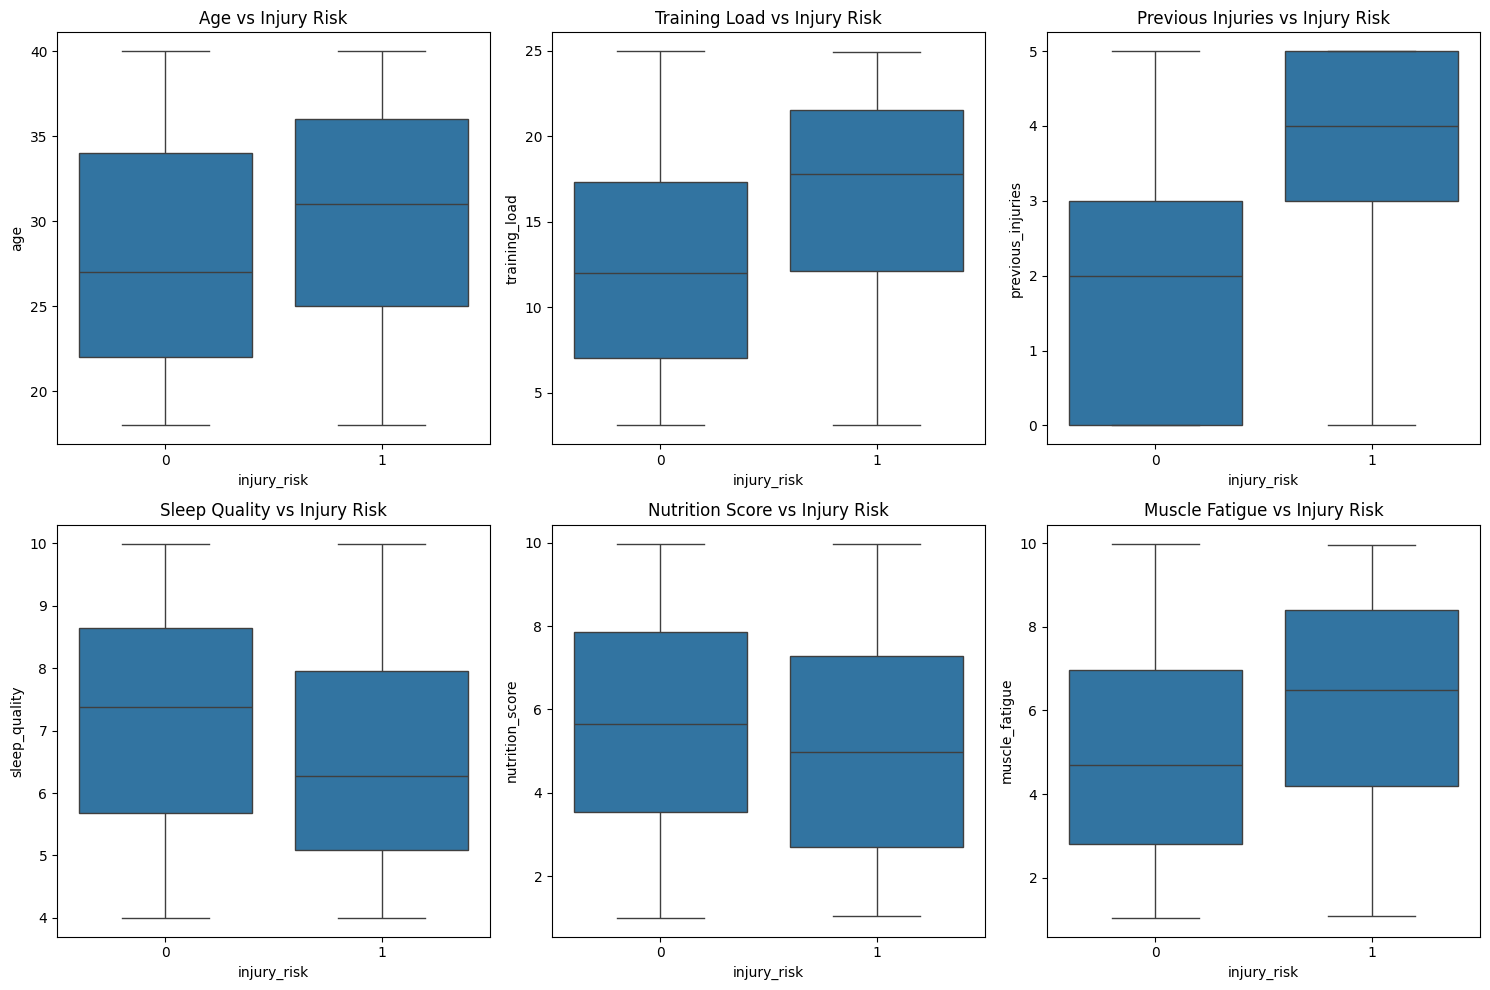

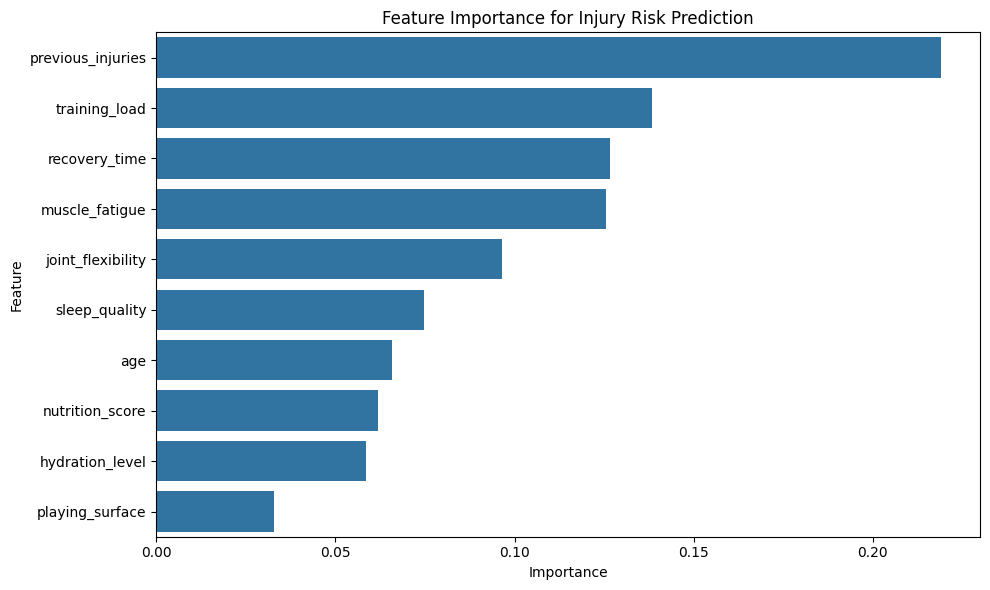


Training Random Forest model...
Training Logistic Regression model...
Training Support Vector Machine model...

Evaluating models...

Random Forest Performance Metrics:
Accuracy: 0.8950
Precision: 0.8767
Recall: 0.8421
F1 Score: 0.8591
AUC-ROC: 0.9508

Confusion Matrix:
[[115   9]
 [ 12  64]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.93      0.92       124
           1       0.88      0.84      0.86        76

    accuracy                           0.90       200
   macro avg       0.89      0.88      0.89       200
weighted avg       0.89      0.90      0.89       200


Logistic Regression Performance Metrics:
Accuracy: 0.9850
Precision: 0.9740
Recall: 0.9868
F1 Score: 0.9804
AUC-ROC: 0.9997

Confusion Matrix:
[[122   2]
 [  1  75]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       124
           1       0.97      0.99      0.98        76


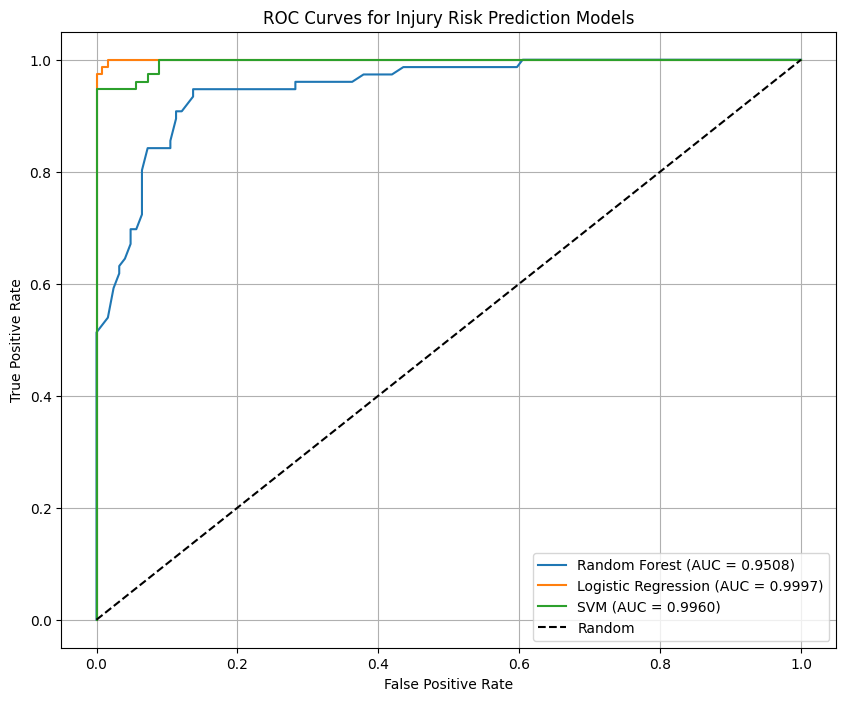

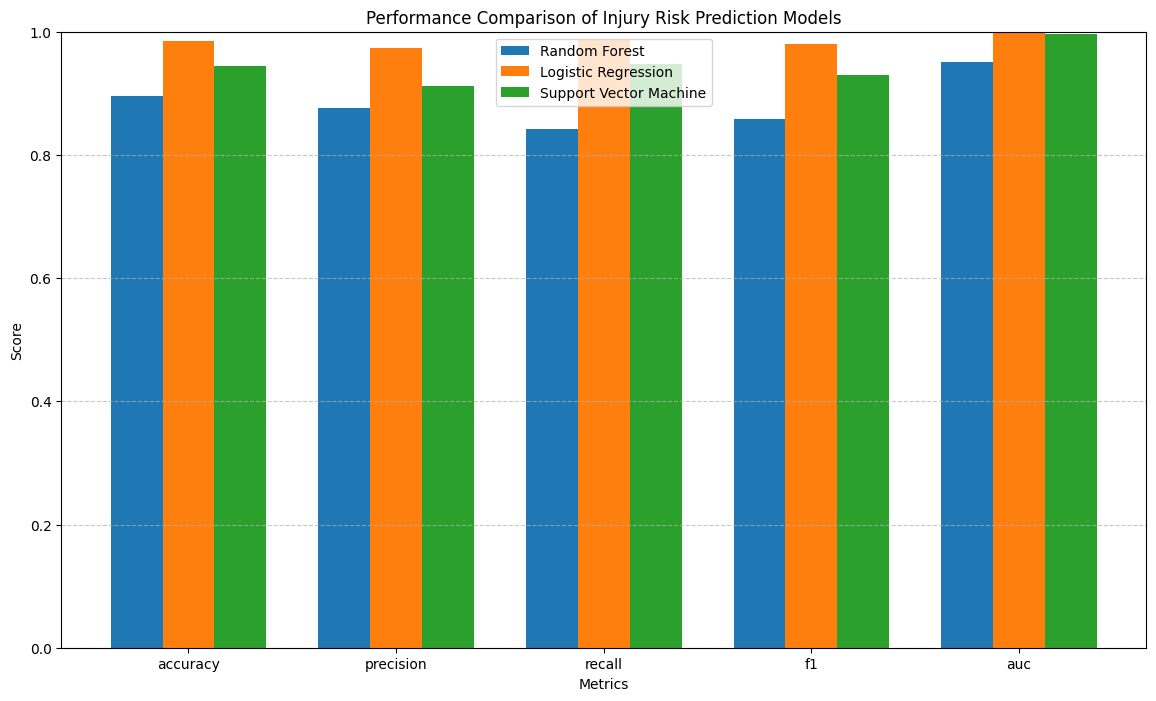


Performing injury location prediction...

Injury Location Prediction Accuracy: 0.28378378378378377

Injury Location Classification Report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00        10
           2       0.20      0.24      0.22        17
           3       0.35      0.58      0.43        26
           4       0.40      0.13      0.20        15
           5       0.00      0.00      0.00         6

    accuracy                           0.28        74
   macro avg       0.19      0.19      0.17        74
weighted avg       0.25      0.28      0.24        74



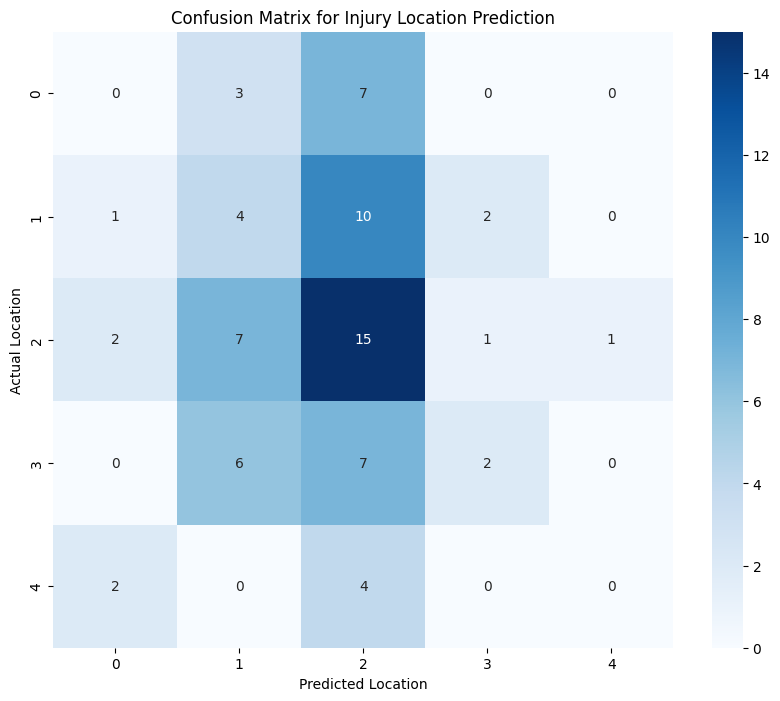

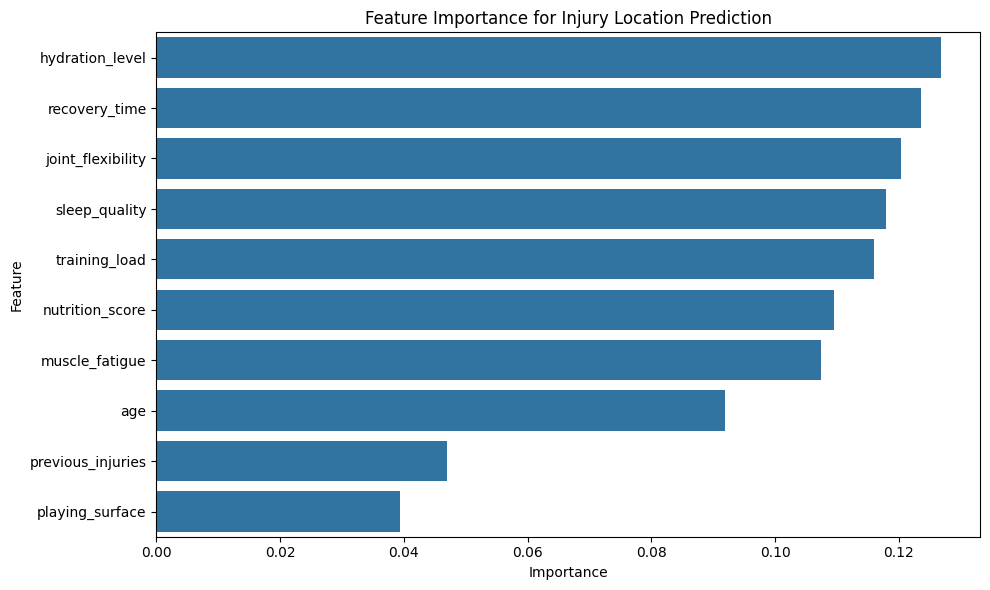


Performing recovery period prediction...

Recovery Period Prediction Metrics:
Mean Squared Error: 47.9809
Root Mean Squared Error: 6.9268
Mean Absolute Error: 5.2020
R² Score: 0.5354


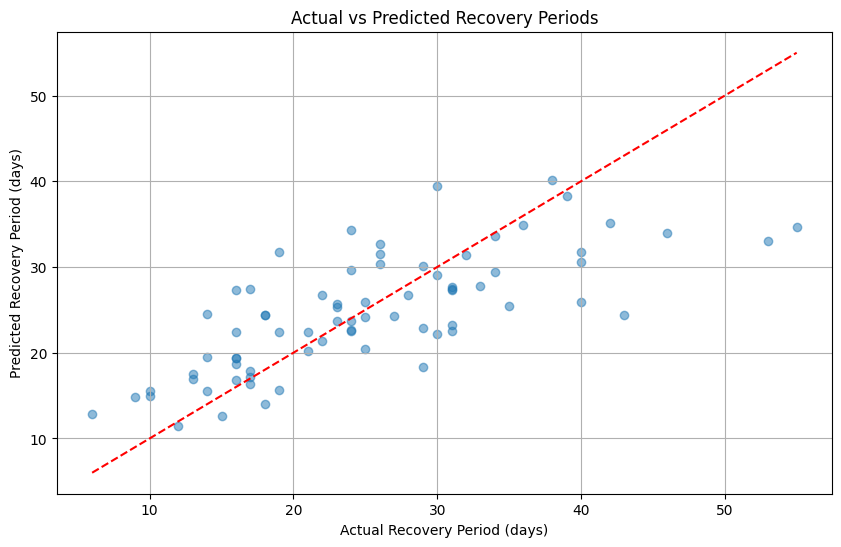


Creating comprehensive model comparison visualizations...


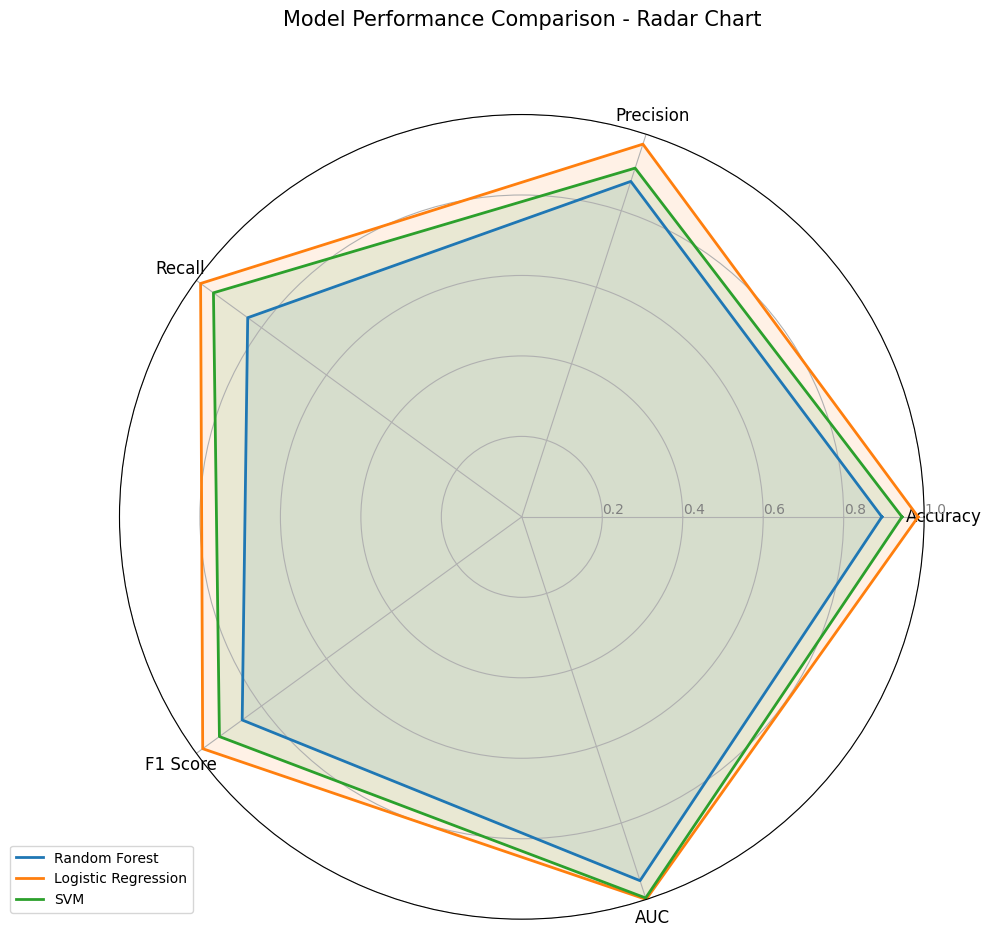

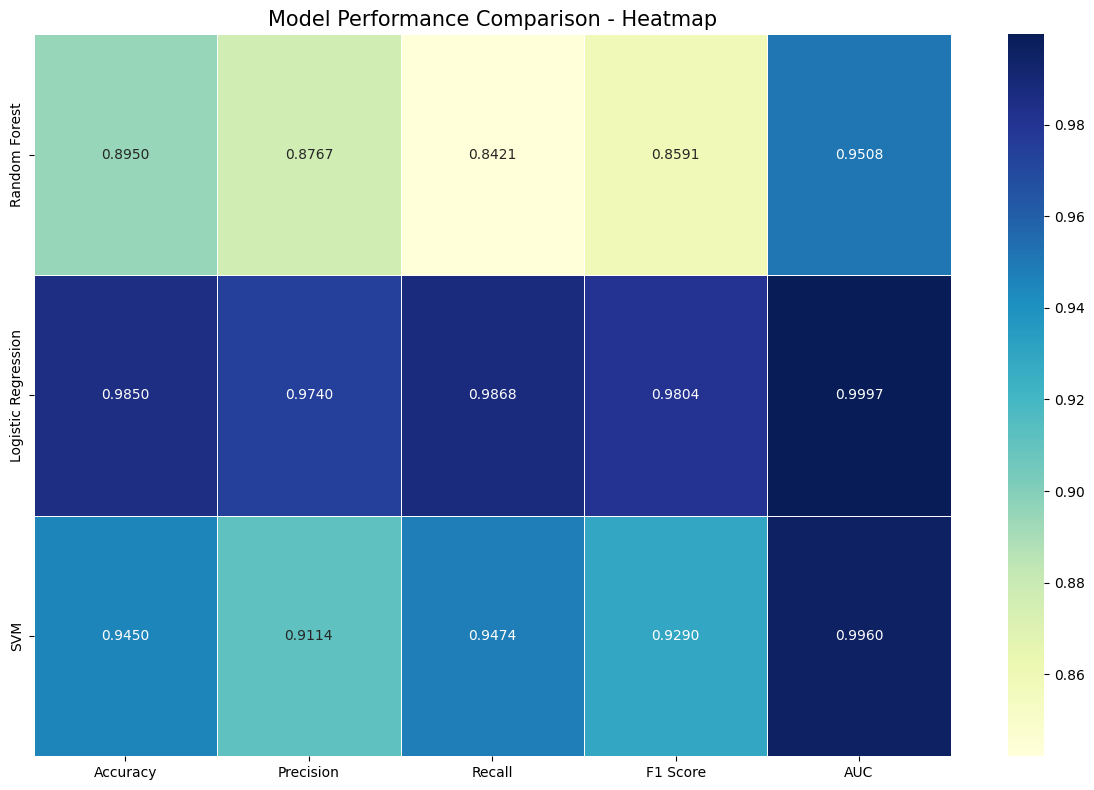

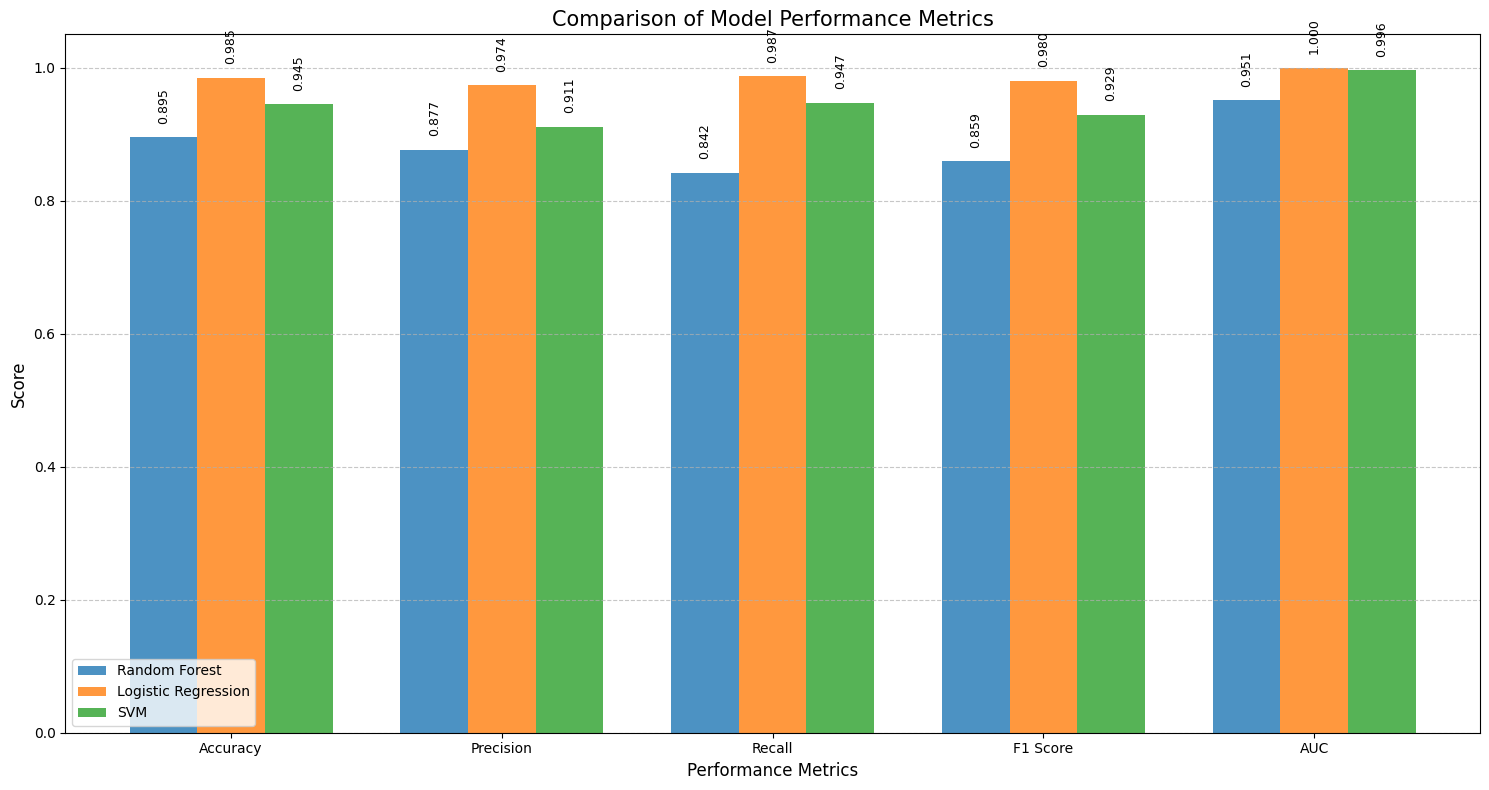


SPORTS INJURY PREDICTION - FINAL REPORT

1. Project Overview:
This project implements machine learning models to predict:
   - Injury risk (binary classification)
   - Injury location (multiclass classification)
   - Recovery period (regression)

2. Dataset Summary:
   - Total samples: 1000
   - Athletes at injury risk: 369 (36.9%)
   - Features used: age, training_load, previous_injuries, recovery_time, sleep_quality, nutrition_score, muscle_fatigue, joint_flexibility, hydration_level, playing_surface

3. Injury Risk Prediction Model Comparison:
                 model  accuracy  precision   recall       f1      auc
         Random Forest     0.895   0.876712 0.842105 0.859060 0.950764
   Logistic Regression     0.985   0.974026 0.986842 0.980392 0.999682
Support Vector Machine     0.945   0.911392 0.947368 0.929032 0.995968

   Best performing model: Logistic Regression

4. Injury Location Prediction:
   - Accuracy: 0.2838
   - Most important features:
     * hydration_level: 0.1268


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

def generate_sports_injury_dataset(n_samples=1000):

    age = np.random.randint(18, 41, n_samples)
    training_load = np.random.uniform(3, 25, n_samples)
    previous_injuries = np.random.randint(0, 6, n_samples)

    recovery_time = np.zeros(n_samples)
    for i in range(n_samples):
        if previous_injuries[i] > 0:
            recovery_time[i] = np.random.uniform(5, 60, 1)[0]

    sleep_quality = np.random.uniform(4, 10, n_samples)
    nutrition_score = np.random.uniform(1, 10, n_samples)
    muscle_fatigue = np.random.uniform(1, 10, n_samples)
    joint_flexibility = np.random.uniform(1, 10, n_samples)
    hydration_level = np.random.uniform(1, 10, n_samples)
    playing_surface = np.random.randint(0, 4, n_samples)

    risk_factor = (
        0.3 * (age - 18) / 22 +
        0.5 * (training_load - 3) / 22 +
        0.7 * previous_injuries / 5 +
        0.3 * recovery_time / 60 +
        0.4 * (10 - sleep_quality) / 6 +
        0.3 * (10 - nutrition_score) / 9 +
        0.6 * muscle_fatigue / 9 +
        0.4 * (10 - joint_flexibility) / 9 +
        0.3 * (10 - hydration_level) / 9 +
        0.2 * playing_surface / 3
    )

    risk_factor = (risk_factor - min(risk_factor)) / (max(risk_factor) - min(risk_factor))

    injury_risk = (risk_factor > 0.5).astype(int)

    injury_location = np.zeros(n_samples, dtype=int)

    for i in range(n_samples):
        if injury_risk[i] == 1:

            probs = [0.1, 0.25, 0.3, 0.2, 0.15]

            if age[i] > 30:
                probs[3] += 0.1
                probs[1] += 0.05

            if playing_surface[i] >= 2:
                probs[0] += 0.15

            if muscle_fatigue[i] > 7:
                probs[2] += 0.1

            probs = [p/sum(probs) for p in probs]

            injury_location[i] = np.random.choice(np.arange(1, 6), p=probs)

    recovery_period = np.zeros(n_samples)

    for i in range(n_samples):

        if injury_risk[i] == 1:

            base_recovery = {1: 14, 2: 28, 3: 21, 4: 30, 5: 10}

            modifier = (
                (1.0 + (age[i] - 18) / 44) *
                (1.0 - (sleep_quality[i] - 4) / 12) *
                (1.0 - (nutrition_score[i] - 1) / 18) *
                (1.0 + (previous_injuries[i]) / 10)
            )

            random_factor = np.random.uniform(0.7, 1.3)

            recovery_period[i] = int(
                base_recovery[injury_location[i]] *
                modifier *
                random_factor
            )

    data = pd.DataFrame({
        'age': age,
        'training_load': training_load,
        'previous_injuries': previous_injuries,
        'recovery_time': recovery_time,
        'sleep_quality': sleep_quality,
        'nutrition_score': nutrition_score,
        'muscle_fatigue': muscle_fatigue,
        'joint_flexibility': joint_flexibility,
        'hydration_level': hydration_level,
        'playing_surface': playing_surface,
        'injury_risk': injury_risk,
        'injury_location': injury_location,
        'recovery_period': recovery_period
    })

    return data

data = generate_sports_injury_dataset(1000)

print("Dataset Preview:")
display(data.head())

print("\nDataset Information:")
display(data.describe())

print("\nTarget Variable Distribution:")
print(f"Injury Risk: {data['injury_risk'].value_counts().to_dict()}")
print(f"Injury Location: {data['injury_location'].value_counts().to_dict()}")

plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlations')
plt.tight_layout()
plt.show()

X = data.drop(['injury_risk', 'injury_location', 'recovery_period'], axis=1)
y_risk = data['injury_risk']

rf_for_importance = RandomForestClassifier(n_estimators=100, random_state=42)
rf_for_importance.fit(X, y_risk)

features_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_for_importance.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=features_importance_df)
plt.title('Feature Importance for Injury Risk Prediction')
plt.tight_layout()
plt.show()

X_train, X_test, y_train, y_test = train_test_split(
    X, y_risk, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

rf_preds = rf_model.predict(X_test_scaled)
rf_probs = rf_model.predict_proba(X_test_scaled)[:, 1]

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

lr_preds = lr_model.predict(X_test_scaled)
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]

svm_model = SVC(probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)

svm_preds = svm_model.predict(X_test_scaled)
svm_probs = svm_model.predict_proba(X_test_scaled)[:, 1]